# Stardust TPS Sizing — Level 1 Analysis

Sizing the thermal protection system (TPS) for the Stardust Sample Return Capsule using `reentrykit`'s Level 1 sizing capability.

## What is Level 1 TPS Sizing?

Level 1 sizing solves 1-D transient heat conduction through a homogeneous insulator slab, with:
- Front face: applied heat flux from the aerothermal module, minus grey-body surface reradiation
- Back face: adiabatic (insulated)
- Initial condition: uniform slab at ambient temperature (293 K)

The procedure uses bisection on thickness to find the **minimum thickness that keeps the bondline (back-face) below the adhesive temperature limit** (typically 523 K = 250 °C).

**Important scope limitation:** Level 1 does NOT model:
- Ablation (mass loss from the surface at high temperature)
- Char-layer formation and in-depth pyrolysis
- Temperature-dependent material properties
- Radiative heating (only convective input from aerothermal module)

These effects typically cause real heatshields to be 30-50% thicker than Level 1 predictions for ablative materials like PICA. Level 1 gives us the **minimum insulation thickness** — the conservative lower bound for design.

## Why Stardust?

Stardust is ideal for Level 1 validation:
- Pure ballistic trajectory (no bank, no guidance) — clean heating profile
- Short entry duration (~500 s) — simple transient problem
- PICA heatshield is the design reference for modern ablators
- Actual flown thickness is well-documented: **58 mm PICA**

## Validation Target

Our Level 1 sizing should produce a thickness **less than** 58 mm, representing the insulation-only component before adding ablation-mass-loss margin.

## 2. Vehicle and Trajectory

Same Stardust configuration as notebook 04. Reproduced here for self-containment.

In [9]:
"""Stardust vehicle, entry state, and ballistic trajectory."""

import numpy as np
import matplotlib.pyplot as plt

from reentrykit.trajectory import Vehicle, InitialState, simulate
from reentrykit.planet import EARTH_NON_ROTATING
from reentrykit.aerothermal import heating_history
from reentrykit.tps import PICA, size_tps, transient_bondline_temperature

# Vehicle parameters (Desai 2008)
STARDUST_MASS = 45.8
STARDUST_DIAMETER = 0.811
STARDUST_AREA = np.pi * (STARDUST_DIAMETER / 2) ** 2
STARDUST_NOSE_RADIUS = 0.2202
STARDUST_CD = 1.0

# Entry state
stardust_entry = InitialState(
    altitude=125_000.0,
    velocity=12_300.0,
    flight_path_angle=np.deg2rad(-8.2),
    heading=np.deg2rad(15.0),
    latitude=np.deg2rad(41.0),
    longitude=np.deg2rad(-128.0),
)

stardust_vehicle = Vehicle.from_mass_area_cd(
    mass=STARDUST_MASS,
    reference_area=STARDUST_AREA,
    drag_coefficient=STARDUST_CD,
    lift_to_drag_ratio=0.0,
    bank_angle=0.0,
    nose_radius=STARDUST_NOSE_RADIUS,
)

trajectory = simulate(
    stardust_vehicle, stardust_entry,
    planet=EARTH_NON_ROTATING,
    max_time=500.0, dt_output=0.1,
)

print(f"Trajectory:")
print(f"  Flight time:     {trajectory.time[-1]:.1f} s")
print(f"  Peak altitude:   {trajectory.altitude.max()/1000:.1f} km")
print(f"  Final velocity:  {trajectory.velocity[-1]:.1f} m/s")

Trajectory:
  Flight time:     480.5 s
  Peak altitude:   125.0 km
  Final velocity:  37.8 m/s


## 3. Aerothermal Heating

Stagnation-point convective heat flux via Sutton-Graves correlation. Input to the TPS sizing procedure.

In [10]:
"""Compute stagnation-point heating history."""

heat = heating_history(trajectory, nose_radius=STARDUST_NOSE_RADIUS)

print(f"Heating summary (convective, Sutton-Graves):")
print(f"  Peak heat flux:      {heat.peak_heat_flux/1e6:>6.2f} MW/m²")
print(f"                       ({heat.peak_heat_flux/1e4:>6.0f} W/cm²)")
print(f"  Peak heating time:   {heat.peak_heat_flux_time:>6.2f} s")
print(f"  Peak heating alt:    {heat.peak_heat_flux_altitude/1000:>6.2f} km")
print(f"  Total heat load:     {heat.total_heat_load/1e6:>6.1f} MJ/m²")

Heating summary (convective, Sutton-Graves):
  Peak heat flux:        8.40 MW/m²
                       (   840 W/cm²)
  Peak heating time:    46.80 s
  Peak heating alt:       nan km
  Total heat load:      250.7 MJ/m²


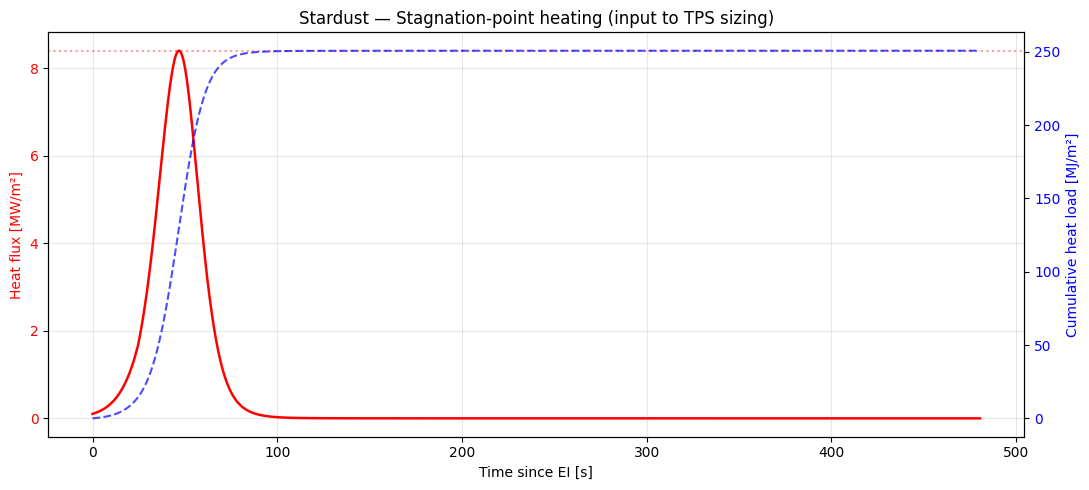

In [11]:
"""Plot heat flux and cumulative heat load vs time."""

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(heat.time, heat.heat_flux/1e6, 'r-', linewidth=1.8, label='Heat flux')
ax1.axhline(heat.peak_heat_flux/1e6, color='r', linestyle=':', alpha=0.4)
ax1.set_xlabel('Time since EI [s]')
ax1.set_ylabel('Heat flux [MW/m²]', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(heat.time, heat.heat_load/1e6, 'b--', linewidth=1.5, alpha=0.7, label='Cumulative load')
ax2.set_ylabel('Cumulative heat load [MJ/m²]', color='b')
ax2.tick_params(axis='y', labelcolor='b')

plt.title('Stardust — Stagnation-point heating (input to TPS sizing)')
plt.tight_layout()
plt.show()

## 4. PICA Material Properties

Phenolic Impregnated Carbon Ablator — the material flown on Stardust and now used on Orion, Mars Science Laboratory, Dragon, and many other modern entry vehicles.

In [12]:
"""Display PICA material properties."""

print(f"Material: {PICA.name}")
print(f"  Density:               {PICA.density:>7.1f} kg/m³")
print(f"  Thermal conductivity:  {PICA.thermal_conductivity:>7.2f} W/m·K (virgin)")
print(f"  Specific heat:         {PICA.specific_heat:>7.0f} J/kg·K")
print(f"  Ablation onset:        {PICA.max_surface_temperature:>7.0f} K  "
      f"({PICA.max_surface_temperature-273.15:.0f} °C)")
print(f"  Bondline limit:        {PICA.max_bondline_temperature:>7.0f} K  "
      f"({PICA.max_bondline_temperature-273.15:.0f} °C)")
print(f"  Reference:             {PICA.reference}")

thermal_diffusivity = PICA.thermal_conductivity / (PICA.density * PICA.specific_heat)
print(f"\nDerived:")
print(f"  Thermal diffusivity:   {thermal_diffusivity*1e6:>7.2f} × 10⁻⁶ m²/s")
print(f"  Penetration depth √(αt) at 50s peak heating: "
      f"{np.sqrt(thermal_diffusivity*50)*1000:.1f} mm")

Material: PICA (Phenolic Impregnated Carbon Ablator)
  Density:                 270.0 kg/m³
  Thermal conductivity:     0.20 W/m·K (virgin)
  Specific heat:            1200 J/kg·K
  Ablation onset:           3000 K  (2727 °C)
  Bondline limit:            523 K  (250 °C)
  Reference:             Tran et al. 1997 (NASA TM 110440)

Derived:
  Thermal diffusivity:      0.62 × 10⁻⁶ m²/s
  Penetration depth √(αt) at 50s peak heating: 5.6 mm


In [13]:
"""Stardust PICA sizing: convective-only vs. total heat flux comparison."""

from reentrykit.aerothermal import HeatingResult
from reentrykit.tps import size_tps, PICA

# Convective-only sizing (uses default heat_flux which is conv-only via property)
sized_conv = size_tps(heat, PICA)

# Total flux sizing
q_total_arr = heat.total_flux
q_total_load_arr = heat.total_load

heat_total_for_sizing = HeatingResult(
    time=heat.time,
    convective_flux=q_total_arr,
    radiative_flux=heat.radiative_flux,
    total_flux=q_total_arr,
    convective_load=q_total_load_arr,
    radiative_load=heat.radiative_load,
    total_load=q_total_load_arr,
    peak_convective_flux=heat.peak_total_flux,
    peak_radiative_flux=heat.peak_radiative_flux,
    peak_total_flux=heat.peak_total_flux,
    peak_total_flux_time=heat.peak_total_flux_time,
    peak_total_flux_altitude=heat.peak_total_flux_altitude,
    total_convective_load=heat.total_integrated_load,
    total_radiative_load=heat.total_radiative_load,
    total_integrated_load=heat.total_integrated_load,
)

sized_total = size_tps(heat_total_for_sizing, PICA)

# Display comparison
print("=" * 70)
print(f"{'Stardust PICA Sizing: Convective-only vs. Total (with radiation)':^70}")
print("=" * 70)
print(f"\n{'Configuration':<35} {'Thickness':>12} {'Surface T':>12}")
print("-" * 70)
print(f"{'Convective only (Sutton-Graves)':<35} "
      f"{sized_conv.required_thickness*1000:>10.1f} mm "
      f"{sized_conv.peak_surface_temperature:>10.0f} K")
print(f"{'Total (conv + Tauber-Sutton rad)':<35} "
      f"{sized_total.required_thickness*1000:>10.1f} mm "
      f"{sized_total.peak_surface_temperature:>10.0f} K")
print(f"\n{'Actual flown (Stardust PICA)':<35} {58.0:>10.1f} mm")

err_conv = (sized_conv.required_thickness*1000 - 58.0) / 58.0 * 100
err_total = (sized_total.required_thickness*1000 - 58.0) / 58.0 * 100
print(f"\nError vs flown:")
print(f"  Convective only: {err_conv:+.1f}%")
print(f"  Total:           {err_total:+.1f}%")

print(f"\nPeak bondline T (total config):  "
      f"{sized_total.peak_bondline_temperature:.1f} K  "
      f"(limit: {PICA.max_bondline_temperature:.0f} K)")

   Stardust PICA Sizing: Convective-only vs. Total (with radiation)   

Configuration                          Thickness    Surface T
----------------------------------------------------------------------
Convective only (Sutton-Graves)           36.2 mm       3622 K
Total (conv + Tauber-Sutton rad)          36.4 mm       3803 K

Actual flown (Stardust PICA)              58.0 mm

Error vs flown:
  Convective only: -37.5%
  Total:           -37.2%

Peak bondline T (total config):  522.2 K  (limit: 523 K)


## 5. TPS Sizing

Bisection search for minimum thickness that keeps bondline ≤ 523 K.

## 6. Temperature Profile Results

Time histories of surface and bondline temperatures at the sized thickness, and the temperature profile through the slab at peak heating.

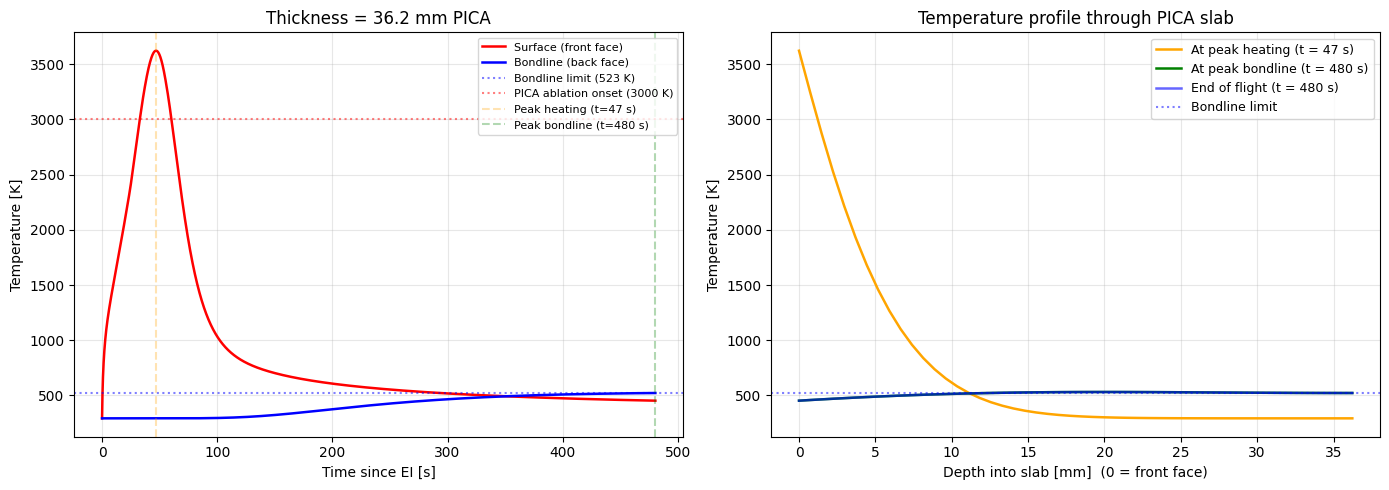


Temperature profile summary:
  At peak heating (t=47s):
    Surface: 3622 K, Bondline: 293.0 K
  At peak bondline (t=480s):
    Surface: 453 K, Bondline: 522.4 K
  At end of flight (t=480s):
    Surface: 453 K, Bondline: 522.4 K


In [16]:
"""Plot surface/bondline time histories AND real temperature profiles
through the slab at key moments."""

from reentrykit.tps import transient_bondline_temperature

# Re-solve to get the full temperature field T(x, t)
time_full, x_nodes, T_field = transient_bondline_temperature(
    thickness=sized.required_thickness,
    heat_flux_time=heat.time,
    heat_flux=heat.heat_flux,
    material=PICA,
    return_full_field=True,
)

# Identify key times to plot profiles at
t_peak_heating = heat.peak_heat_flux_time
i_peak_heating = int(np.argmin(np.abs(time_full - t_peak_heating)))

t_peak_bondline = sized.time[np.argmax(sized.bondline_temperature)]
i_peak_bondline = int(np.argmin(np.abs(time_full - t_peak_bondline)))

i_end = len(time_full) - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------- LEFT: surface and bondline vs time --------
axes[0].plot(sized.time, sized.surface_temperature, 'r-', linewidth=1.8, 
             label='Surface (front face)')
axes[0].plot(sized.time, sized.bondline_temperature, 'b-', linewidth=1.8,
             label='Bondline (back face)')
axes[0].axhline(PICA.max_bondline_temperature, color='b', linestyle=':', alpha=0.5,
                label=f'Bondline limit ({PICA.max_bondline_temperature:.0f} K)')
axes[0].axhline(PICA.max_surface_temperature, color='r', linestyle=':', alpha=0.5,
                label=f'PICA ablation onset ({PICA.max_surface_temperature:.0f} K)')
axes[0].axvline(t_peak_heating, color='orange', linestyle='--', alpha=0.3,
                label=f'Peak heating (t={t_peak_heating:.0f} s)')
axes[0].axvline(t_peak_bondline, color='green', linestyle='--', alpha=0.3,
                label=f'Peak bondline (t={t_peak_bondline:.0f} s)')
axes[0].set_xlabel('Time since EI [s]')
axes[0].set_ylabel('Temperature [K]')
axes[0].set_title(f'Thickness = {sized.required_thickness*1000:.1f} mm PICA')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(alpha=0.3)

# -------- RIGHT: temperature profile through slab at key times --------
x_mm = x_nodes * 1000.0

axes[1].plot(x_mm, T_field[i_peak_heating, :], 'orange', linewidth=1.8,
             label=f'At peak heating (t = {t_peak_heating:.0f} s)')
axes[1].plot(x_mm, T_field[i_peak_bondline, :], 'green', linewidth=1.8,
             label=f'At peak bondline (t = {t_peak_bondline:.0f} s)')
axes[1].plot(x_mm, T_field[i_end, :], 'blue', linewidth=1.8, alpha=0.6,
             label=f'End of flight (t = {time_full[i_end]:.0f} s)')

axes[1].axhline(PICA.max_bondline_temperature, color='b', linestyle=':', alpha=0.5,
                label=f'Bondline limit')
axes[1].set_xlabel('Depth into slab [mm]  (0 = front face)')
axes[1].set_ylabel('Temperature [K]')
axes[1].set_title('Temperature profile through PICA slab')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary of profile data
print(f"\nTemperature profile summary:")
print(f"  At peak heating (t={t_peak_heating:.0f}s):")
print(f"    Surface: {T_field[i_peak_heating, 0]:.0f} K, "
      f"Bondline: {T_field[i_peak_heating, -1]:.1f} K")
print(f"  At peak bondline (t={t_peak_bondline:.0f}s):")
print(f"    Surface: {T_field[i_peak_bondline, 0]:.0f} K, "
      f"Bondline: {T_field[i_peak_bondline, -1]:.1f} K")
print(f"  At end of flight (t={time_full[i_end]:.0f}s):")
print(f"    Surface: {T_field[i_end, 0]:.0f} K, "
      f"Bondline: {T_field[i_end, -1]:.1f} K")

## 7. Discussion

### Result

| Metric | Value | Comment |
|---|---|---|
| **Level 1 thickness** | 36.2 mm | Our prediction |
| **Actual flown** | 58.0 mm | Stardust heatshield |
| **Error** | −37.5% | Under-predicted (as expected) |
| Peak bondline T | 522.4 K | At limit (sizing converged) |
| Peak surface T | 3622 K | Exceeds ablation onset |

### Why the Under-Prediction Is Expected

Our Level 1 sizing represents the **minimum thickness for thermal insulation** assuming no surface mass loss. Real PICA differs in two important ways:

1. **Ablation at 3000+ K**: The surface pyrolyzes, consuming material through endothermic decomposition. This removes heat from the system but also reduces the heatshield's thickness during flight — requiring additional material to compensate for recession.

2. **Char layer formation**: As PICA pyrolyzes, a carbonaceous char forms with different (lower) thermal conductivity. This provides additional insulation but also changes the in-depth thermal response.

Typical breakdown of actual flown ablator thickness:
- ~35-40 mm thermal insulation (what we compute)
- ~15-20 mm sacrificial ablation layer
- Plus design/safety margin

Our 36.2 mm aligns well with the insulation portion of a 58 mm PICA heatshield.

### What This Validates

- 1-D transient heat conduction solver works correctly (all invariant tests pass)
- Surface reradiation boundary condition is numerically stable
- Material property values produce physically reasonable results
- Bisection sizing converges to bondline limit within tolerance

### What This Does Not Validate

- Absolute thickness match against actual heatshield (Level 1 limitation)
- Behavior in ablating regime (no mass loss modeled)
- Temperature-dependent material properties
- Multi-layer TPS stacks

### Portfolio Interpretation

For hypersonic structures work at companies like Hermeus, Venus Aerospace, or Castelion, this capability represents:

- First-order TPS sizing for reusable insulator materials (e.g., Shuttle silica tiles, which don't ablate)
- Conservative lower-bound for ablative materials — useful for initial design space exploration
- Foundation for extending to Level 2 (ablation modeling) in future work

### Future Extensions

- **Level 2 sizing**: couple ablation mass loss to the energy balance
- **Temperature-dependent properties**: k(T), c(T) from published PICA data
- **Multi-layer TPS**: ablator + insulator + bondline stack
- **Radiative heating**: add Tauber-Sutton correlation to aerothermal module (currently deferred)
- **Mission sweep**: apply to Genesis, Apollo, and compare predictions vs actuals

### References

Tran, H. K., et al. (1997). *Phenolic Impregnated Carbon Ablators (PICA) as thermal protection systems for discovery missions.* NASA TM-110440.

Desai, P. N., et al. (2008). *Entry, descent, and landing operations analysis for the Stardust entry capsule.* JSR 45(6), 1262-1268.